In [41]:
import numpy as np

file = input("Enter file name: ")

data = np.loadtxt(file)
x = data[:,0]
y = data[:,1]

print(f"\nx min: {x.min()}")
print(f"x max: {x.max()}")
print(f"x mean: {x.mean()}")

print(f"\ny min: {y.min()}")
print(f"y max: {y.max()}")
print(f"y mean: {y.mean()}")

y_med = np.median(y)
y2 = (y - y_med)**2

print(f"\n{y2}")

Enter file name: text1

x min: 1.2
x max: 9.0
x mean: 4.24

y min: 1.5
y max: 7.8
y mean: 4.74

[ 0.81 12.25  0.    7.84  5.76]


In [7]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(np.concatenate((a, b)))

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print(f"\n{np.concatenate((a, b))}")
print(f"\n{np.concatenate((a, b), axis=0)}")
print(f"\n{np.concatenate((a, b), axis=1)}")

[1 2 3 4 5 6]

[[1 2]
 [3 4]
 [5 6]
 [7 8]]

[[1 2]
 [3 4]
 [5 6]
 [7 8]]

[[1 2 5 6]
 [3 4 7 8]]


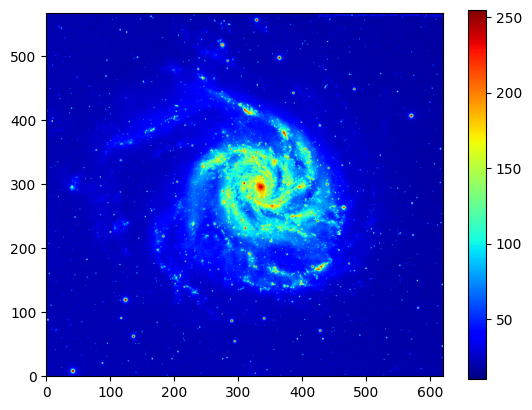

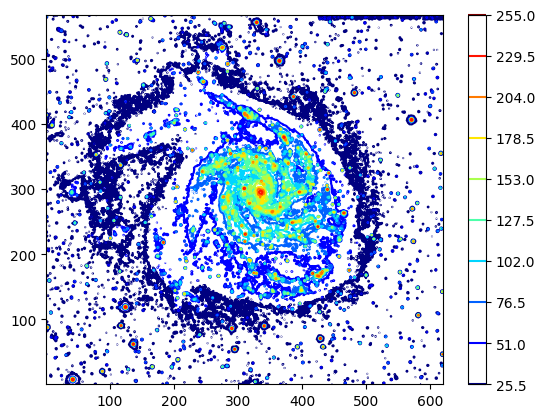

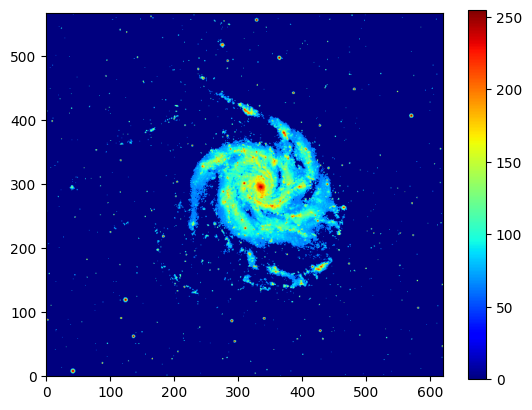

In [44]:
import numpy as np
import imageio.v3 as iio 
import matplotlib.pyplot as plt

image = iio.imread('m101BW.jpg')

plt.figure()
plt.imshow(image, cmap='jet',origin="lower")
plt.colorbar()
plt.show()

plt.figure()
levels = np.linspace(image.max() * 0.1, image.max(), 10)
plt.contour(image, levels=levels, cmap='jet',origin="lower")
plt.colorbar()
plt.show()

f = np.percentile(image,90)
fimage = np.where(image >= f, image,0)

plt.figure()
plt.imshow(fimage, cmap='jet',origin="lower")
plt.colorbar()
plt.show()

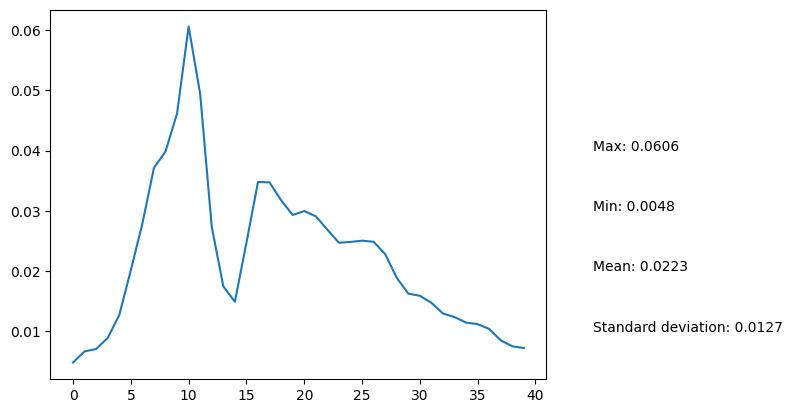

In [32]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt')

cube = data.reshape(40,50,70)

mx = 35
mt = 25

z = cube[:, mt, mx]

plt.figure()
plt.plot(z)
plt.text(45, 0.04, f"Max: {np.max(z):.4f}")
plt.text(45, 0.03, f"Min: {np.min(z):.4f}")
plt.text(45, 0.02, f"Mean: {np.mean(z):.4f}")
plt.text(45, 0.01, f"Standard deviation: {np.std(z):.4f}")
plt.show()

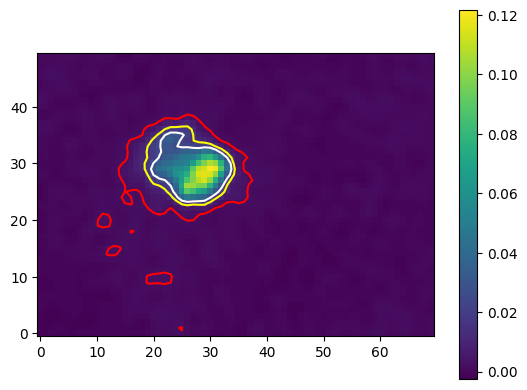

In [40]:
plane = cube[0, :, :]

m = np.mean(plane)
s = np.std(plane)

plt.figure()
plt.imshow(plane,origin='lower')
plt.colorbar()
plt.contour(plane,levels=[m,m+s,m+2*s],colors=['red','yellow','white'])
plt.show()

In [21]:
from scipy.constants import c 

class Galaxy:
    """Class for redshift calculation of galaxies"""

    caH_0 = 3968.5          # Calcium H line in rest frame 
    c = c / 1000            
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline

    def redshift(self):
        z = (self.caH - self.caH_0)/self.caH
        return z

    def velocity(self):
        return self.redshift() * self.c


g = Galaxy("NGC 6767", calciumHline=4000)

print(f"Galaxy: {g.name}")
print(f"Redshift: z = {g.redshift()}")
print(f"Velocity: v = {g.velocity()} km/s")


Galaxy: NGC 6767
Redshift: z = 0.007875
Velocity: v = 2360.86560675 km/s


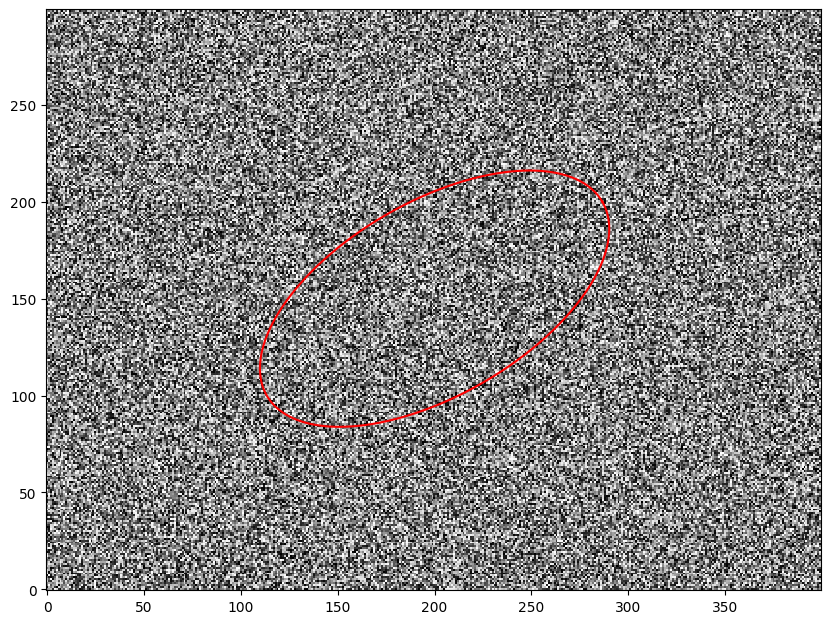

In [20]:
import numpy as np
from matplotlib.pyplot import figure, show

Nx = 400
Ny = 300
data = np.random.random((Ny, Nx))

fig = figure(figsize=(10, 8))
ax = fig.add_subplot(1,1,1)
ax.imshow(data, interpolation='none', origin="lower", cmap='gray')


cx, cy = Nx / 2, Ny / 2
a = 100       
b = 50        
ang = 30.0  

t = np.linspace(0, 2 * np.pi, 500)
angrad = np.radians(ang)

x = cx + a * np.cos(t) * np.cos(angrad) - b * np.sin(t) * np.sin(angrad)
y = cy + a * np.cos(t) * np.sin(angrad) + b * np.sin(t) * np.cos(angrad)

ax.plot(x, y, color='red')

show()